In [1]:
%cd ..
%load_ext autoreload
%autoreload 2

/home/dongmin/userdata/open-score-string-quartets


/home/dongmin/.local/share/virtualenvs/open-score-string-quartets-wd2Cnojv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from pathlib import Path

import math
import random

import json
import csv
import strictyaml as syaml

from tqdm import tqdm
import matplotlib.pyplot as plt

import cv2
import numpy as np

from scripts.utils import PathLike
from scripts.utils import get_ts, dformat, dprint
from scripts.const import excluded_pages

from scripts.mscx_utils import ( 
  convert_mscx_to_musicxml,
  convert_mscx_to_pdf,
  convert_pdf_to_images,
)

/home/dongmin/.local/share/virtualenvs/open-score-string-quartets-wd2Cnojv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
root_dir = Path.cwd()
data_dir = root_dir / 'data'
score_dir = root_dir / 'scores'

In [4]:
data_dir, score_dir

(PosixPath('/home/dongmin/userdata/open-score-string-quartets/data'),
 PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores'))

## Load metadata

In [5]:
with open(data_dir / 'scores_w_infos.yaml') as f:
  metadata = syaml.load(f.read())

metadata = metadata.data

## Converting MuseScore files
**all .mscx files were edited using MuseScore3 v3.6.2**

### Convert MuseScore files to MusicXML

In [6]:
convert_mscx_to_musicxml(
  metadata, 
  score_dir,
  './mscore'
)

100%|██████████| 122/122 [05:39<00:00,  2.78s/it]


### Count n_systems

In [10]:
from scripts.count_n_systems import main as count_n_systems
count_n_systems(Path.cwd())

Number of scores: 122


  0%|          | 0/122 [00:00<?, ?it/s]

100%|██████████| 122/122 [00:32<00:00,  3.81it/s]


### Convert MuseScore files to pdf

In [11]:
convert_mscx_to_pdf(metadata, score_dir, './mscore')

100%|██████████| 122/122 [02:59<00:00,  1.47s/it]


## Image Preprocessing

### convert_pdf_to_images

In [12]:
convert_pdf_to_images(metadata, score_dir)

  0%|          | 0/122 [00:00<?, ?it/s]CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to M

### Detect systems

In [ ]:
from scripts.detect_systems import main as detect_systems
detect_systems(Path.cwd())

#### validate bboxs

In [8]:
with open(data_dir / 'scores_w_infos.yaml') as f:
  metadata = syaml.load(f.read())

metadata = metadata.data

In [10]:
from scripts.utils import load_bboxs

error_scores = []
error_pages = []

for sqid, infos in metadata.items():
  mscore_dir = score_dir / infos['path']
  n_pages = int(infos['n_pages'])
  n_systems = int(infos['n_systems'])
  
  bbox_paths = (mscore_dir / 'images' / 'synthetic' / 'original').glob(f'sq{sqid}:*_yolo_bboxs.txt')
  bbox_paths = list(sorted(bbox_paths))
  
  pred = 0
  
  for p_i, b_p in enumerate(bbox_paths):
    bboxs = load_bboxs(b_p, min_ratio=0.2)
    pred += len(bboxs)
    
    if len(bboxs) != int(infos['n_systems_per_page'][p_i]):
      error_pages.append((
        sqid, b_p, int(infos['n_systems_per_page'][p_i]), len(bboxs)
      ))
  
  if pred != n_systems:
    img_dir = mscore_dir / 'images' / 'synthetic' / 'original'
    error_scores.append((sqid, mscore_dir, n_systems, pred))


len(error_scores), len(error_pages)

(0, 0)

In [8]:
len(set(i[0] for i in error_scores)), len(set(i[0] for i in error_pages)), set(i[0] for i in error_scores) - set(i[0] for i in error_pages), set(i[0] for i in error_pages) - set(i[0] for i in error_scores)

(22, 22, set(), set())

#### debug specific sample

Delius,_Frederick/String_Quartet_in_E_minor 0020
6 4 4


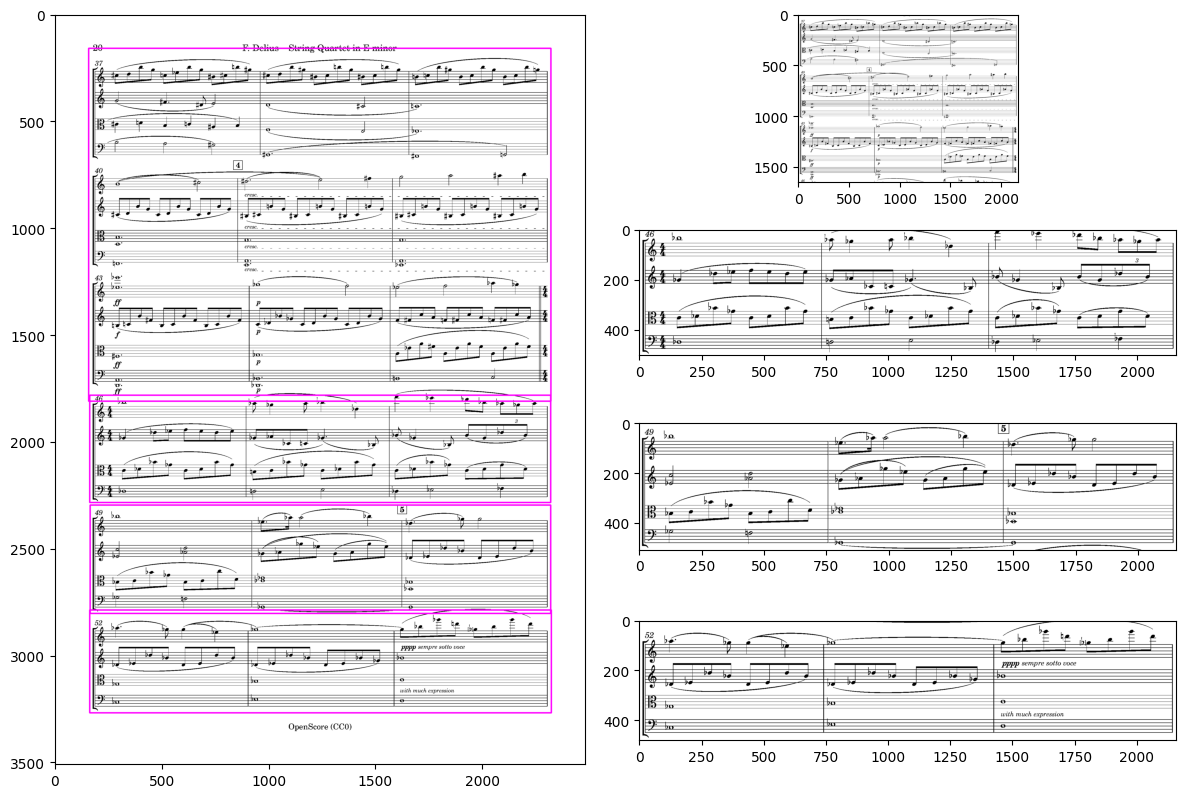

In [10]:
from matplotlib.gridspec import GridSpec
from scripts.utils import load_bboxs

error_page = error_pages[19]

sqid, b_p, ns, prd = error_page

i_p = b_p.parent / b_p.name.replace("_yolo_bboxs.txt", ".png")
img = cv2.imread(str(i_p), cv2.IMREAD_UNCHANGED)

print(metadata[sqid]['path'], i_p.stem.split(':')[-1])

bboxs = load_bboxs(b_p, min_ratio=0.2)

n = len(bboxs)
fig_width = 12
fig_height = 8

print(ns, prd, n)

# Create figure with custom grid layout
fig = plt.figure(figsize=(fig_width, fig_height))
gs = GridSpec(n, 2, width_ratios=[1, 1], height_ratios=[1]*n)

ax_left = fig.add_subplot(gs[:, 0])
left_image = img.copy()

for x1, y1, x2, y2 in bboxs:
  cv2.rectangle(left_image, (x1, y1), (x2, y2), (255, 0, 255), 5)

ax_left.imshow(left_image)

right_images = []
for i, (x1, y1, x2, y2) in enumerate(bboxs):
  ax_right = fig.add_subplot(gs[i, 1])
  right_image = img[y1:y2, x1:x2]
  ax_right.imshow(right_image)

plt.tight_layout()
plt.show()

#### check all edge cases

In [ ]:
from matplotlib.gridspec import GridSpec

for i, (sqid, b_p, ns, prd) in enumerate(error_pages):
  i_p = b_p.parent / b_p.name.replace("_yolo_bboxs.txt", ".png")
  img = cv2.imread(str(i_p), cv2.IMREAD_UNCHANGED)
  
  print(i, metadata[sqid]['path'], i_p.stem.split(':')[-1])
  print(ns, prd)
  
  bboxs = load_bboxs(b_p, min_ratio=0.2)
  
  n = len(bboxs)
  fig_width = 12
  fig_height = 8

  # Create figure with custom grid layout
  fig = plt.figure(figsize=(fig_width, fig_height))
  gs = GridSpec(n, 2, width_ratios=[1, 1], height_ratios=[1]*n)

  ax_left = fig.add_subplot(gs[:, 0])
  left_image = img.copy()
  
  for x1, y1, x2, y2 in bboxs:
    cv2.rectangle(left_image, (x1, y1), (x2, y2), (255, 0, 255), 5)
  
  ax_left.imshow(left_image)

  right_images = []
  for i, (x1, y1, x2, y2) in enumerate(bboxs):
    ax_right = fig.add_subplot(gs[i, 1])
    right_image = img[y1:y2, x1:x2]
    ax_right.imshow(right_image)

  plt.tight_layout()
  plt.show()

### Crop detected system

In [ ]:
from scripts.crop_systems import main as crop_systems
crop_systems(Path.cwd())

### Resize cropped images

In [6]:
from scripts.resize_imgs import main as resize_imgs
resize_imgs(Path.cwd(), 18)

# of pages: 2904


  0%|          | 3/2904 [00:00<02:04, 23.29it/s]

100%|██████████| 2904/2904 [01:49<00:00, 26.61it/s]


## Convert MusicXML to LMXE

In [14]:
from scripts.musicxml_to_lmxe import main as musicxml_to_lmxe

base_dir = Path.cwd()
log_path = base_dir / f'lmxe_{get_ts()}.log'

musicxml_to_lmxe(base_dir, log_path)

sq7158117:  57%|█████▋    | 69/122 [00:33<00:28,  1.84it/s] 

sq8823783: 100%|██████████| 122/122 [00:55<00:00,  2.19it/s] 


### update vocabulary

In [15]:
from modules.lmxe.lmxe.vocabulary import print_vocabulary

with open(data_dir / 'vocabulary.txt', 'w') as f:
  print_vocabulary(f)

### Validate n_systems

In [16]:
lmxe_paths = score_dir.glob('**/lmxe/*.page.lmxe')
lmxe_paths = list(sorted(lmxe_paths))
len(lmxe_paths), lmxe_paths[:3]

(2904,
 [PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Andrée,_Elfrida/String_Quartet_in_A_major/lmxe/sq7313978:0001.page.lmxe'),
  PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Andrée,_Elfrida/String_Quartet_in_A_major/lmxe/sq7313978:0002.page.lmxe'),
  PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Andrée,_Elfrida/String_Quartet_in_A_major/lmxe/sq7313978:0003.page.lmxe')])

In [17]:
error_lmxe = []

for l_p in tqdm(lmxe_paths):
  with open(l_p, 'r') as f:
    lmxe = f.read()
  
  systems = lmxe.split('\n\n')
  
  pred = len(systems)

  sqid, pidx = l_p.stem.replace('.page', '').split(':')
  sqid = sqid.replace('sq', '')
  pidx = int(pidx) - 1
  n_systems = int(metadata[sqid]['n_systems_per_page'][pidx])
  
  if pred != n_systems:
    img_path = l_p.parent.parent / 'images' / 'original' / f'{l_p.stem}.png'
    error_lmxe.append((img_path, n_systems, pred))

100%|██████████| 2904/2904 [00:00<00:00, 48999.35it/s]


In [18]:
len(error_lmxe)

0

## Metadata w/file_paths

In [38]:
with open(data_dir / 'scores_w_infos.yaml') as f:
  metadata = syaml.load(f.read())

metadata = metadata.data

In [42]:
for sqid, infos in metadata.items():
  mscore_dir = score_dir / infos['path']
  
  pages = []
  
  for pidx, n_systems in enumerate(infos['n_systems_per_page']):
    pidx = str(pidx + 1).zfill(4)
    lmxe_paths = list(sorted((mscore_dir / 'lmxe').glob(f'sq{sqid}:{pidx}:*.system.lmxe')))
    
    assert len(lmxe_paths) == int(n_systems), f"Mismatch in {sqid} page {pidx}: {len(lmxe_paths)} vs {n_systems}"
    
    img_paths = [ 
      p.parent.parent / 'images' / 'synthetic' / 'crop_resized' / p.name.replace('.system.lmxe', '.png') 
      for p in lmxe_paths
    ]
    
    pages.append(list(zip(img_paths, lmxe_paths)))
  
  metadata[sqid]['pages'] = pages

In [45]:
for sqid, infos in metadata.items():
  if len(infos['pages']) != int(infos['n_pages']):
    print(f"Mismatch in {sqid}: {infos['n_pages']} vs {len(infos['pages'])}")
  
  total_n_paths = 0
  for pidx, paths in enumerate(infos['pages']):
    if len(paths) != int(infos['n_systems_per_page'][pidx]):
      print(f"Mismatch in {sqid} page {pidx + 1}: {len(paths)} vs {infos['n_systems_per_page'][pidx]}")
    
    total_n_paths += len(paths)
  
  if total_n_paths != int(infos['n_systems']):
    print(f"Mismatch in {sqid} page {pidx + 1}: {total_n_paths} vs {infos['n_systems']}")


In [35]:
str(Path(*img_paths[0].parts[-2:]))

'crop_resized/sq8823783:0065:0001.png'

In [46]:
for sqid, infos in metadata.items():
  pages = infos['pages']
  
  new_pages = []
  for paths in pages:
    paths = [
      [
        str(Path(*img_path.parts[-4:])),  # Keep only the last 4 parts of the path
        str(Path(*lmxe_path.parts[-2:])),
      ]
      for img_path, lmxe_path in paths
    ]
    
    new_pages.append(paths)

  metadata[sqid]['pages'] = new_pages

In [47]:
with open(data_dir / 'scores_full.yaml', 'w') as f:
  f.write(syaml.as_document(metadata).as_yaml())